# MaStR EDA

# Preparation

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

In [65]:
def convert_date_columns(df):
    global date_columns
    # convert date columns into correct format (only keep date)
    date_columns = df.columns[df.columns.str.contains('date', case=False)]
    for data_col in date_columns:
        print("Column '%s' has %d unique values." % (data_col, df[data_col].nunique()))
        try:
            df[data_col] = pd.to_datetime(df[data_col], format='%Y-%m-%d')
        except: # shorted updated date to omit time
            df[data_col] = pd.to_datetime([x.split(" ")[0] for x in df[data_col]], format='%Y-%m-%d')
            print("Column '%s' has now %d unique values." % (data_col, df[data_col].nunique()))
    return df

In [66]:
data_dir = "../data/cleaned/"
infile_plants = "MaStR_plants.csv"
infile_units = "MaStR_units.csv"

# 1. Power plant data

## Load and inspect data

In [67]:
# load data
df = pd.read_csv(data_dir+infile_plants)

In [68]:
df.shape

(3180229, 15)

In [69]:
df.tail(3).T

,3180226,3180227,3180228
Unnamed: 0,3180226,3180227,3180228
registration_date,2020-02-07,2020-02-07,2020-02-07
last_updated_date,2020-02-07 08:58:20.781680400,2021-09-10 13:43:59.066299300,2020-02-07 08:44:01.819484200
eeg_commissioning_date,2009-11-02,2012-06-21,2011-07-11
eegMaStR_number,EEG927617131487,EEG967125993344,EEG976761019417
plant_key_eeg,NaN,E41081010000000000000000000186634,E2052301111AA00000000011185200001
plant_identification_number_plant_register_nv,0,0,0
installed_capacity,5.61,163.02,6.08
registration_number_pv_reporting_portal_nv,1,0,1
MieterstromZugeordnet,NaN,NaN,NaN


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3180229 entries, 0 to 3180228
Data columns (total 15 columns):
 #   Column                                         Dtype  
---  ------                                         -----  
 0   Unnamed: 0                                     int64  
 1   registration_date                              object 
 2   last_updated_date                              object 
 3   eeg_commissioning_date                         object 
 4   eegMaStR_number                                object 
 5   plant_key_eeg                                  object 
 6   plant_identification_number_plant_register_nv  int64  
 7   installed_capacity                             float64
 8   registration_number_pv_reporting_portal_nv     int64  
 9   MieterstromZugeordnet                          float64
 10  tender_award                                   float64
 11  plant_operating_status                         int64  
 12  linked_units_MaStR_numbers                

## Date information

In [71]:
# convert to datetime
df = convert_date_columns(df)

Column 'registration_date' has 1654 unique values.
Column 'last_updated_date' has 3172567 unique values.
Column 'last_updated_date' has now 1628 unique values.
Column 'eeg_commissioning_date' has 11258 unique values.


In [72]:
df.head()

,Unnamed: 0,registration_date,last_updated_date,eeg_commissioning_date,eegMaStR_number,plant_key_eeg,plant_identification_number_plant_register_nv,installed_capacity,registration_number_pv_reporting_portal_nv,MieterstromZugeordnet,tender_award,plant_operating_status,linked_units_MaStR_numbers,registration_number_PV_Meldeportal,claim_payment_after_eeg
0,0,2021-01-05,2021-02-14,2020-10-08,EEG989636348222,E21624020128098160007000000100000,0,8.70,0,0.0,0.0,35,SEE945469264627,NaN,NaN
1,1,2021-01-20,2022-05-21,2015-10-09,EEG984858427748,E10843010000000000000083340600001,0,9.36,0,NaN,0.0,35,SEE970978176376,NaN,NaN
2,2,2021-01-05,2021-01-05,2011-06-20,EEG957900505114,E1080601LA00000000000000657500001,0,7.92,0,NaN,0.0,35,SEE907950973319,NaN,NaN
3,3,2021-01-05,2021-01-05,2008-12-19,EEG965793636600,E31887010000000000000000000000257,0,4.14,0,NaN,0.0,35,SEE929254843174,NaN,NaN
4,4,2021-01-05,2021-03-12,2010-08-17,EEG952415280143,E21041011000000000000389477300000,0,4.05,0,NaN,0.0,35,SEE926841754691,NaN,NaN


### Date ranges

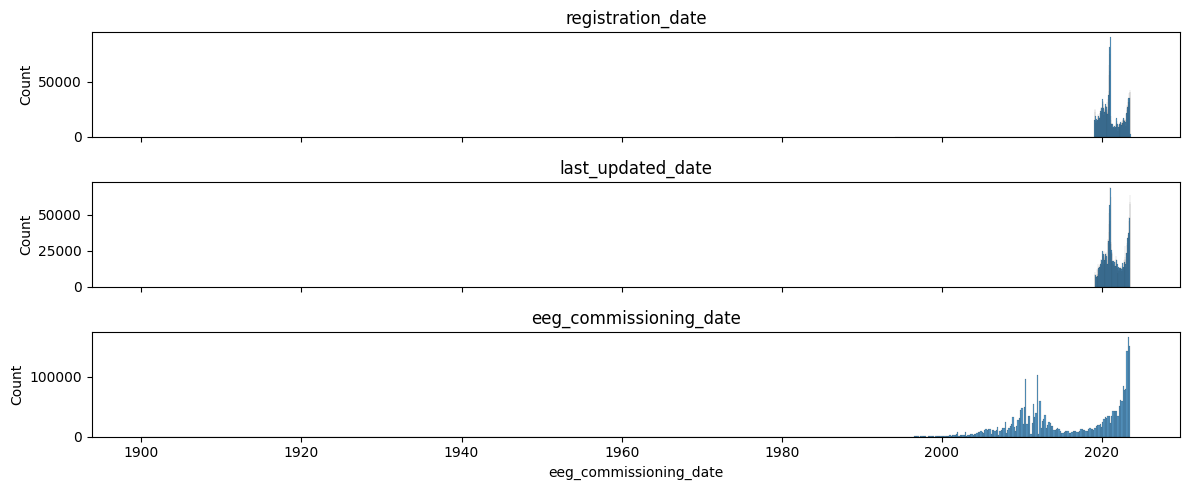

In [73]:
# show distribution of the dates
fig, ax = plt.subplots(3,1, figsize=(12,5), sharex=True)
sns.histplot(df.registration_date, ax=ax[0]).set(title="registration_date")
sns.histplot(df.last_updated_date, ax=ax[1]).set(title="last_updated_date")
sns.histplot(df.eeg_commissioning_date, ax=ax[2]).set(title="eeg_commissioning_date")
fig.tight_layout()
plt.show()

### Old power plants

In [74]:
# minimum value of date columns
df[date_columns].min()

registration_date        1994-03-01
last_updated_date        2019-01-31
eeg_commissioning_date   1900-01-01
dtype: datetime64[ns]

In [75]:
# estimate amount of old power plants 
df[df.eeg_commissioning_date < datetime(1989, 12, 31)].shape

(765, 15)

In [76]:
df[df.eeg_commissioning_date < datetime(1989, 12, 31)]

,Unnamed: 0,registration_date,last_updated_date,eeg_commissioning_date,eegMaStR_number,plant_key_eeg,plant_identification_number_plant_register_nv,installed_capacity,registration_number_pv_reporting_portal_nv,MieterstromZugeordnet,tender_award,plant_operating_status,linked_units_MaStR_numbers,registration_number_PV_Meldeportal,claim_payment_after_eeg
28814,28814,2021-01-09,2021-01-09,1960-12-28,EEG991504095305,NaN,0,2.470,0,NaN,NaN,35,SEE972350678645,NaN,NaN
62164,62164,2021-01-14,2021-09-01,1982-08-25,EEG943919811988,E2166201KIR0000000001900001800001,0,5.268,0,NaN,0.0,35,SEE978460820806,NaN,NaN
78572,78572,2021-01-17,2023-06-07,1963-07-24,EEG916148946936,E11486010000000000000000016100001,0,24.500,0,NaN,0.0,35,SEE912839926287,NaN,NaN
85533,85533,2021-01-18,2021-01-18,1965-09-24,EEG982905182213,NaN,0,15.050,0,NaN,0.0,35,SEE982373744814,NaN,NaN
100340,100340,2022-03-30,2022-03-30,1961-12-30,EEG935447660978,NaN,0,18.000,0,NaN,0.0,35,SEE967795987940,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3158342,3158342,2020-01-30,2020-01-30,1963-10-20,EEG977800198469,NaN,0,29.670,0,NaN,NaN,35,SEE979129751677,NaN,1.0
3159340,3159340,2020-01-31,2020-01-31,1980-06-01,EEG972505185158,NaN,0,5.280,0,NaN,0.0,35,SEE963950336547,NaN,1.0
3162753,3162753,2020-02-04,2020-02-04,1911-04-18,EEG935420725304,E21878015120000000000009747900001,0,8.200,0,NaN,0.0,35,SEE962686417988,NaN,1.0
3164614,3164614,2020-02-02,2020-02-02,1916-03-29,EEG987604214845,E20978010010000300700101020000003,0,3.600,0,NaN,0.0,35,SEE942940047649,NaN,1.0


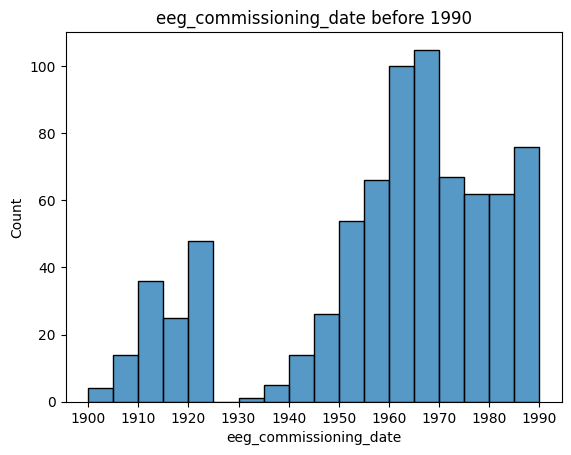

In [77]:
# visualize old power plants
old_plants = df[df.eeg_commissioning_date < datetime(1989, 12, 31)]
sns.histplot(old_plants.eeg_commissioning_date, bins=18).set(title="eeg_commissioning_date before 1990")
plt.show()


> many old powerplants included - here: commissioning date does definitely not refer to start of the production of solar energy!

# 2. Units data

## Load and inspect data

In [78]:
# load data
df_units = pd.read_csv(data_dir+infile_units)

In [79]:
df_units.shape

(3236786, 35)

In [80]:
df_units.head(3).T

,0,1,2
Unnamed: 0,0,1,2
unit_MaStR_number,SEE908860931956,SEE931592559495,SEE959506828024
last_updated_date,2022-02-03 04:30:16.530722600,2020-06-10 15:14:12.695161200,2020-09-02 16:04:49.232047600
location_MaStR_number,SEL905867571413,SEL996215025429,SEL969821171620
network_operator_check_status,1,1,1
plant_operator_MaStR_number,ABR995487677183,ABR919936548978,ABR976648444424
country,84,84,84
state,1402.0,1403.0,1402.0
county,Rems-Murr-Kreis,Oberallgäu,Bodenseekreis
municipality,Backnang,Betzigau,Frickingen


In [81]:
df_units.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3236786 entries, 0 to 3236785
Data columns (total 35 columns):
 #   Column                                     Dtype  
---  ------                                     -----  
 0   Unnamed: 0                                 int64  
 1   unit_MaStR_number                          object 
 2   last_updated_date                          object 
 3   location_MaStR_number                      object 
 4   network_operator_check_status              int64  
 5   plant_operator_MaStR_number                object 
 6   country                                    int64  
 7   state                                      float64
 8   county                                     object 
 9   municipality                               object 
 10  municipality_key                           float64
 11  postal_code                                float64
 12  place                                      object 
 13  registration_date                         

## NaNs

In [82]:
print("%d NaN in total in dataframe" % df_units.isnull().sum().sum())

8836978 NaN in total in dataframe


In [83]:
df_units.isnull().sum()[df_units.isnull().sum()>0]


location_MaStR_number                          61707
plant_operator_MaStR_number                     4424
state                                             25
county                                            25
municipality                                      25
municipality_key                                  25
postal_code                                        2
place                                              2
commissioning_date                             57400
power_generation_unit_name                        10
remote_control_nb                              46254
feed_type                                      25924
assigned_active_power_inverter                  3370
location                                          57
eegMaStR_number                                56557
common_inverter_with_storage                   77080
number_of_modules                              84989
power_limitation                               87424
uniform_orientation_and_inclination_angle     

### Skip if essential data is missing

In [84]:
# check for co-occurrence of NaNs in number of modules and commissioning dates
df_units[['number_of_modules', 'commissioning_date']].isna().value_counts()


number_of_modules  commissioning_date
False              False                 3095419
True               False                   83967
False              True                    56378
True               True                     1022
Name: count, dtype: int64

In [85]:
# require number of modules and commissioning date
print(df_units.shape)
df_units_backup = df_units.copy()
df_units.dropna(axis=0, subset=['number_of_modules', 'commissioning_date'], thresh=2, inplace=True)
print(df_units.shape)


(3236786, 35)
(3095419, 35)


In [86]:
print("%d NaN in total in dataframe" % df_units.isnull().sum().sum())


8083155 NaN in total in dataframe


In [87]:
df_units.isnull().sum()[df_units.isnull().sum()>0]


location_MaStR_number                           4346
plant_operator_MaStR_number                     4344
state                                             20
county                                            20
municipality                                      20
municipality_key                                  20
postal_code                                        2
place                                              2
power_generation_unit_name                         9
remote_control_nb                              37541
feed_type                                      19417
common_inverter_with_storage                   64321
power_limitation                               68541
uniform_orientation_and_inclination_angle      56238
main_orientation                               35886
main_orientation_inclination_angle             54359
usage_area                                    397924
network_operator_check_date                  2325207
secondary_orientation                        2

## Date information

In [88]:
# convert to datetime
df_units = convert_date_columns(df_units)

Column 'last_updated_date' has 3020726 unique values.
Column 'last_updated_date' has now 1629 unique values.
Column 'registration_date' has 1629 unique values.
Column 'commissioning_date' has 11438 unique values.
Column 'network_operator_check_date' has 1628 unique values.


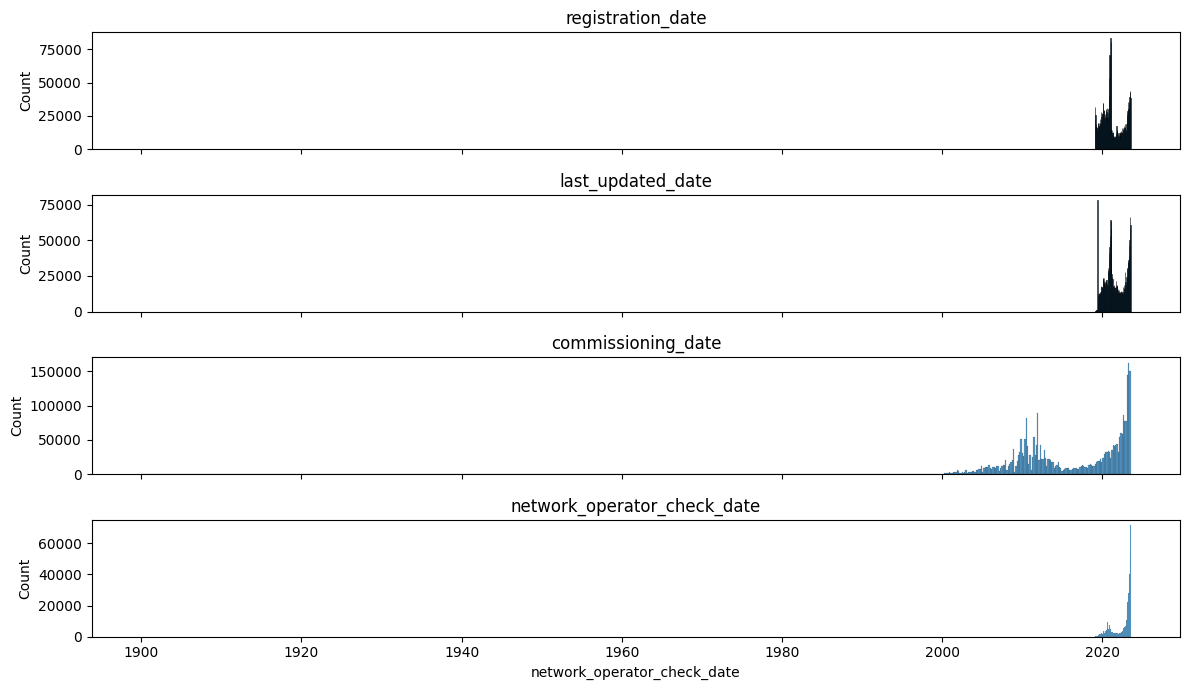

In [89]:
# show distribution of the dates
fig, ax = plt.subplots(4,1, figsize=(12,7), sharex=True)
sns.histplot(df_units.registration_date, ax=ax[0]).set(title="registration_date")
sns.histplot(df_units.last_updated_date, ax=ax[1]).set(title="last_updated_date")
sns.histplot(df_units.commissioning_date, ax=ax[2]).set(title="commissioning_date")
sns.histplot(df_units.network_operator_check_date, ax=ax[3]).set(title="network_operator_check_date")
fig.tight_layout()
plt.show()

In [90]:
# minimum value of date columns
df_units[date_columns].min()

last_updated_date             2019-01-31
registration_date             2019-01-31
commissioning_date            1900-01-01
network_operator_check_date   2019-02-01
dtype: datetime64[ns]

## Number of Modules

In [91]:
df_units.number_of_modules.describe().apply(lambda x: format(x, 'f'))

count    3095419.000000
mean         107.744267
std         2552.488218
min            1.000000
25%           18.000000
50%           29.000000
75%           50.000000
max      1000000.000000
Name: number_of_modules, dtype: object

## Output per Module

In [93]:
df_units["gross_output_kW_per_module"] = df_units.gross_output_kW/df_units.number_of_modules
df_units["net_rated_output_kW_per_module"] = df_units.net_rated_output_kW/df_units.number_of_modules

## Feed type (sampled DF)

In [94]:
# check (non-descriptive) labels of full df
df_units.feed_type.value_counts()

feed_type
689.0    2055095
688.0    1020907
Name: count, dtype: int64

In [95]:
# make columns categorical
df_units.feed_type = df_units.feed_type.astype("category")
df_units.state = df_units.state.astype("category")

In [96]:
# sample data frame
df_units_sample = df_units.sample(300000, random_state=2023)

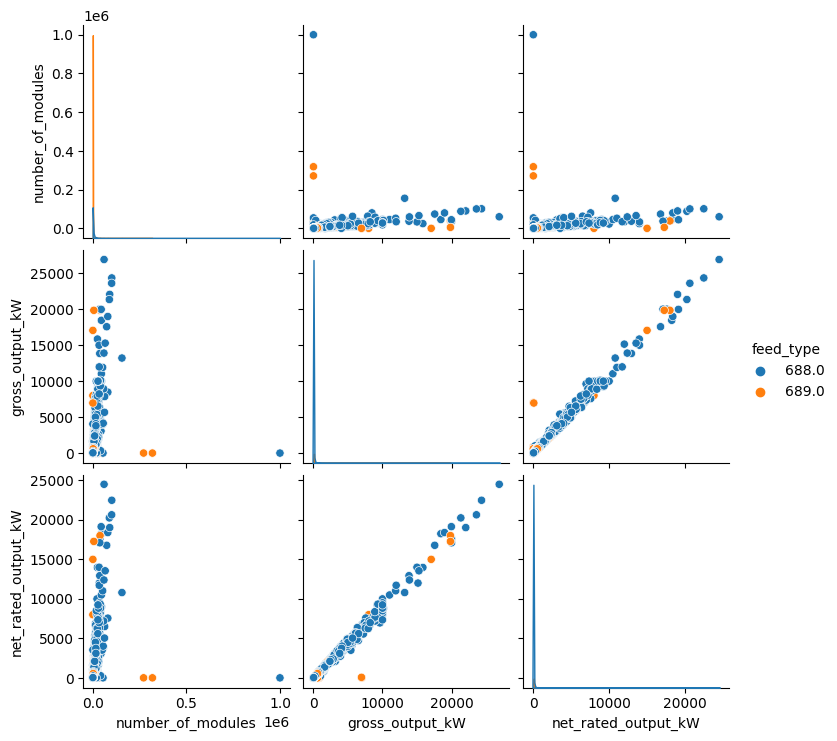

In [97]:
sns.pairplot(df_units_sample[["number_of_modules", "commissioning_date", "feed_type", "gross_output_kW", "net_rated_output_kW"]], hue="feed_type")

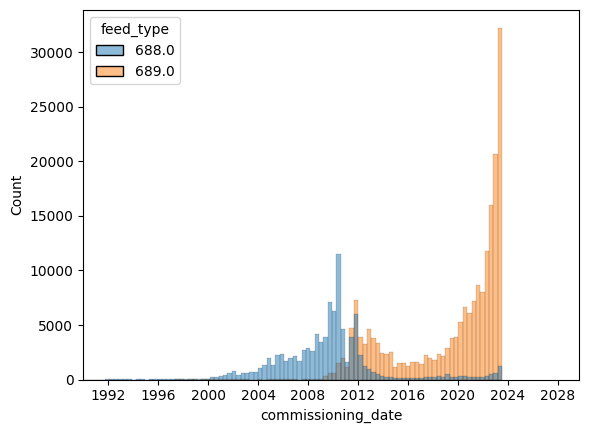

In [98]:
fig = sns.histplot(x=df_units_sample.commissioning_date, hue=df_units_sample.feed_type)
fig.set_xlim(datetime(1989, 12, 31), None)
plt.show()


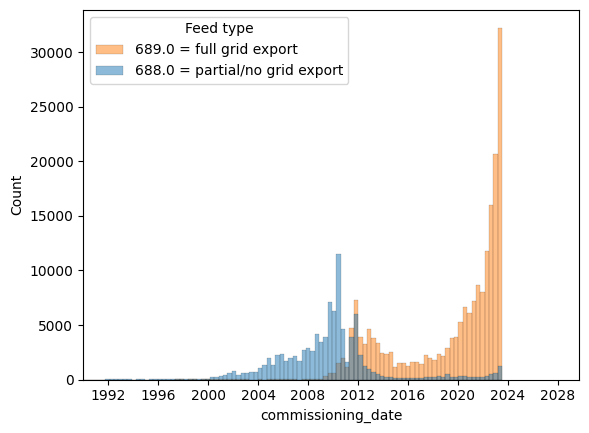

In [116]:
fig = sns.histplot(x=df_units_sample.commissioning_date, hue=df_units_sample.feed_type)
fig.set_xlim(datetime(1989, 12, 31), None)
fig.legend(title='Feed type', loc='upper left', labels=['689.0 = full grid export', '688.0 = partial/no grid export', ])
plt.show()


## Output

[Text(0.5, 1.0, 'Output range by federal state')]

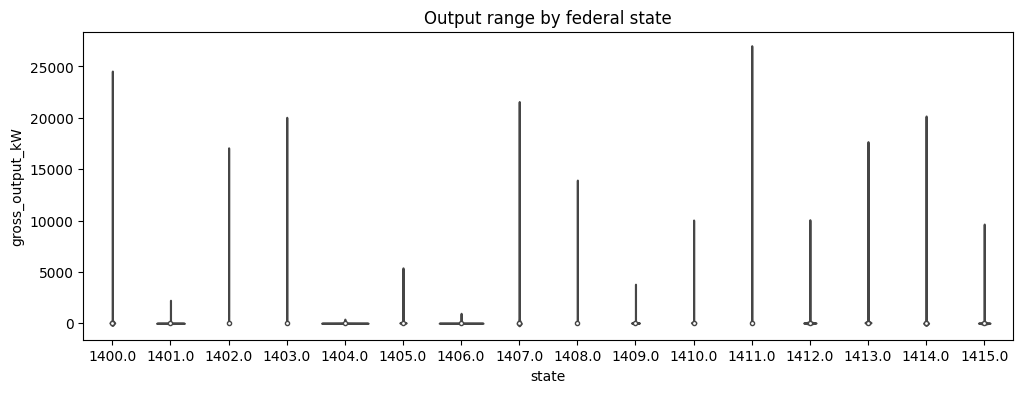

In [100]:
plt.subplots(figsize=(12,4))
fig = sns.violinplot(data=df_units_sample, x="state", y="gross_output_kW")
fig.set(title="Output range by federal state")

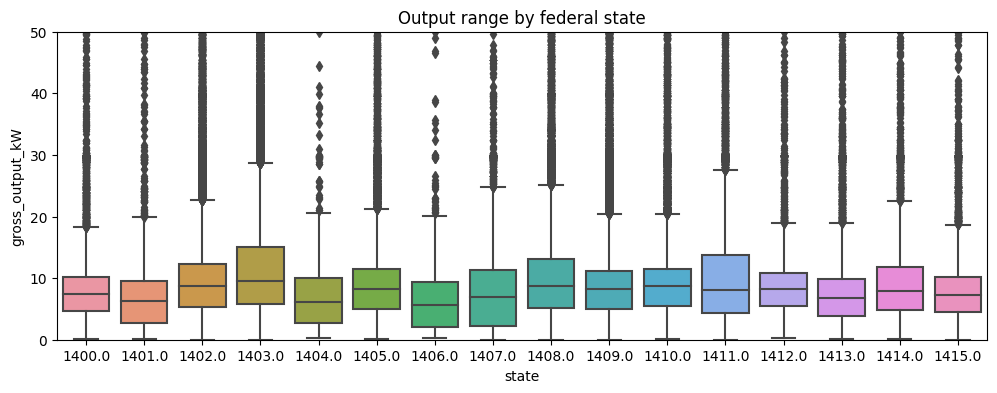

In [101]:
plt.subplots(figsize=(12,4))
fig = sns.boxplot(data=df_units_sample, x="state", y="gross_output_kW")
fig.set_ylim(0, 50)
fig.set(title="Output range by federal state")
plt.show()

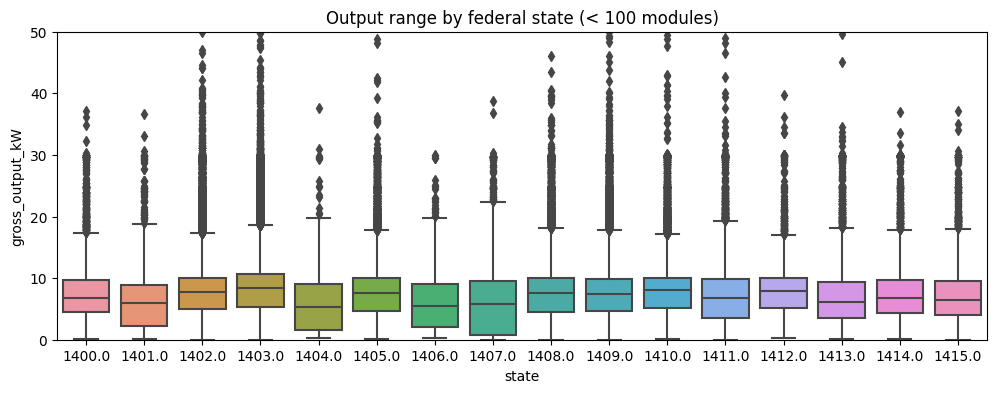

In [102]:
# filter big power plants
plt.subplots(figsize=(12,4))
fig = sns.boxplot(data=df_units_sample[df_units_sample.number_of_modules < 100], x="state", y="gross_output_kW")
fig.set_ylim(0, 50)
fig.set(title="Output range by federal state (< 100 modules)")
plt.show()

## Output per module

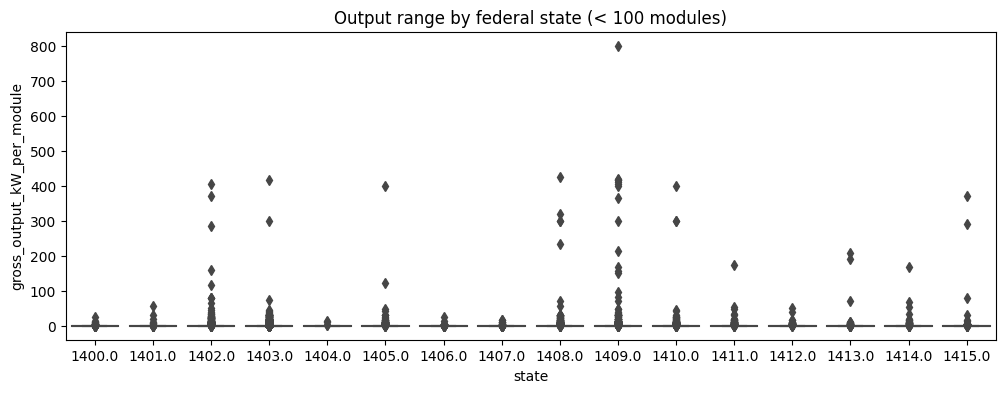

In [105]:
# filter big power plants
plt.subplots(figsize=(12,4))
fig = sns.boxplot(data=df_units_sample, x="state", y="gross_output_kW_per_module")
fig.set(title="Output range by federal state (< 100 modules)")
plt.show()

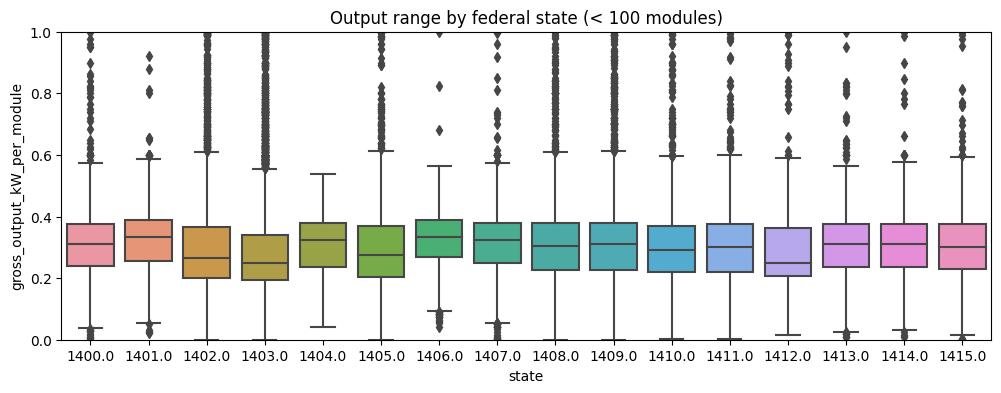

In [108]:
# filter big power plants
plt.subplots(figsize=(12,4))
fig = sns.boxplot(data=df_units_sample, x="state", y="gross_output_kW_per_module")
fig.set_ylim(0, 1)
fig.set(title="Output range by federal state (< 100 modules)")
plt.show()

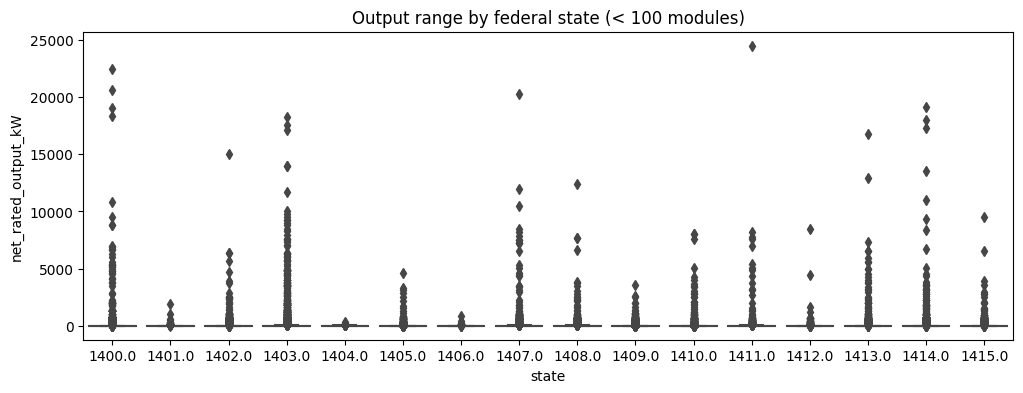

In [110]:
# filter big power plants
plt.subplots(figsize=(12,4))
fig = sns.boxplot(data=df_units_sample, x="state", y="net_rated_output_kW")
fig.set(title="Output range by federal state (< 100 modules)")
plt.show()

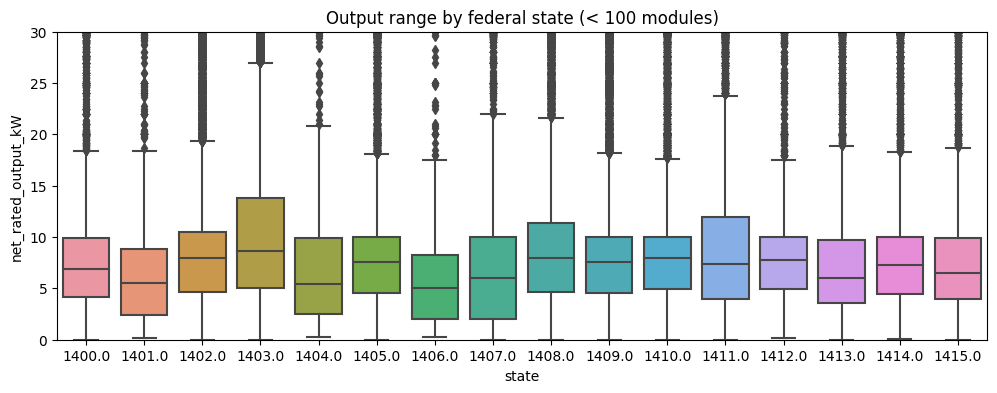

In [114]:
# filter big power plants
plt.subplots(figsize=(12,4))
fig = sns.boxplot(data=df_units_sample, x="state", y="net_rated_output_kW")
fig.set_ylim(0, 30)
fig.set(title="Output range by federal state (< 100 modules)")
plt.show()

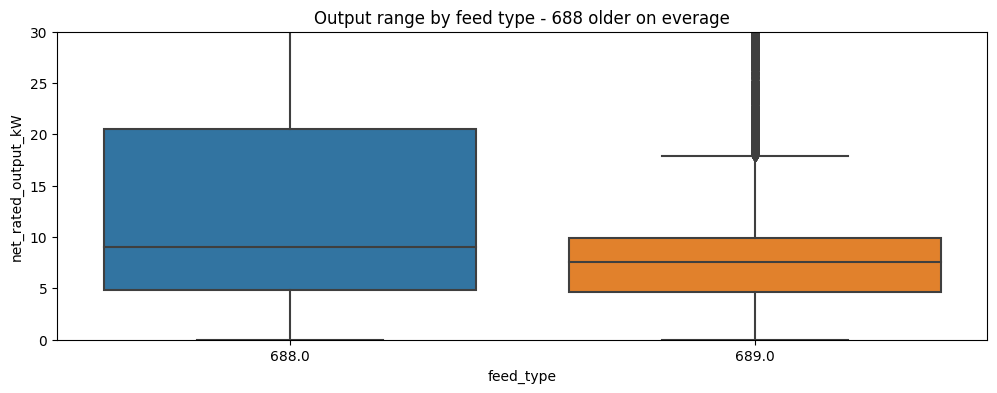

In [117]:
# filter big power plants
plt.subplots(figsize=(12,4))
fig = sns.boxplot(data=df_units_sample, x="feed_type", y="net_rated_output_kW")
fig.set_ylim(0, 30)
fig.set(title="Output range by feed type - 688 older on everage")
plt.show()

# Conclusions


## Power plants
- issue with power plants
    - if old, this definitely refers to other types of energy and is not informative regarding solar energy!

## Units
- still power plants included (e.g. 1 Mio units, commissioned < 1980, ...)
    - eventually filter by `powerplant_number`
- various NaNs
    - data can be skipped if missing `commisioning_data` and `number_of_modules`
- output per module varies drastically
    - different technologies
    - different panel sizes
    - maybe also wrong data added by private people?
- feed_type:
    - Volleinspeisung = generated electricity is sold completely - usually for all private PV starting to operate before 2009
    - Teileinspeisung = generated electricity is used partially or completely by owners of the PV or sold to others without using the grid  
    - accordingly: 
        - 688 = Volleinspeisung (everything sold to the grid)
        - 689 = Teileinspeisung (used partially or completely)